# DataDriven_Soccer_Scouting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from tensorflow.keras import layers, models
import time

import warnings
warnings.filterwarnings("ignore")



start_time = time.time()

## Introduction and EDA

In [2]:
df = pd.read_csv("merged_data.csv")
# Convert 'season' to a more readable format (e.g., '2020 - 2021')
df['season'] = df['season'].astype(str).str.zfill(4)
df['season'] = "20" + df['season'].str[:2] + " - 20" + df['season'].str[2:]

display(df.head())
print('\nRows: {}, Columns: {}'.format(df.shape[0], df.shape[1]))

,league,season,team,player,nation,pos,age,born,Playing Time_MP,Playing Time_Starts,...,Touches_Att 3rd,Touches_Att Pen,Touches_Def 3rd,Touches_Def Pen,Touches_Live,Touches_Mid 3rd,Touches_Touches,Height,Weight,Preferred foot
0,ENG-Premier League,2024 - 2025,Arsenal,Ben White,ENG,DF,26,1997,17,13,...,238,28,214,55,813,367,813,NaN,NaN,NaN
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,"FW,MF",22,2001,25,20,...,715,162,57,6,978,216,979,178.0,65.0,Left
2,ENG-Premier League,2024 - 2025,Arsenal,David Raya,ESP,GK,28,1995,38,38,...,0,0,1388,880,1480,92,1480,183.0,75.0,Right
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,MF,25,1999,35,33,...,733,81,325,82,1948,909,1948,185.0,80.0,Right
4,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Magalhães,BRA,DF,26,1997,28,28,...,225,40,672,189,1873,985,1873,NaN,NaN,NaN



Rows: 4807, Columns: 117


In [3]:
#Removing rows with null values and Goalkeepers (GK)
not_null_df = df.dropna()
not_null_df = not_null_df[not_null_df['pos'] != 'GK']
print('data without null and GKs\n- rows: {} \n- columns: {}'.format(not_null_df.shape[0], not_null_df.shape[1]))
df_backup = df.copy()
df = not_null_df.copy()

data without null and GKs
- rows: 3396 
- columns: 117


In [4]:
# select all not numeric columns
not_numeric_cols = df.select_dtypes(exclude=[np.number]).columns
display(df[not_numeric_cols].head())

,league,season,team,player,nation,pos,Preferred foot
1,ENG-Premier League,2024 - 2025,Arsenal,Bukayo Saka,ENG,"FW,MF",Left
3,ENG-Premier League,2024 - 2025,Arsenal,Declan Rice,ENG,MF,Right
5,ENG-Premier League,2024 - 2025,Arsenal,Gabriel Martinelli,BRA,"FW,MF",Right
6,ENG-Premier League,2024 - 2025,Arsenal,Jakub Kiwior,POL,DF,Left
7,ENG-Premier League,2024 - 2025,Arsenal,Jurriën Timber,NED,DF,Right


In [5]:
# Convert 'Preferred foot' to binary: 1 for 'Right', 0 for 'Left'
df['right_foot'] = df['Preferred foot'].map({'Right': 1, 'Left': 0})
df.drop('Preferred foot', axis=1, inplace=True)

# Identify info columns and create a separate DataFrame for them
info_columns = ['league', 'season', 'team', 'player', 'nation', 'pos', 'born', 'age']
df_info = df[[col for col in df.columns if col.lower() in info_columns]].copy()
numeric_features = df.select_dtypes(include=[np.number]).columns
features = [col for col in numeric_features if col.lower() not in info_columns]

X = df[features].copy()

print(f"Matrix 'X' shape: {X.shape[0]} players x {X.shape[1]} statistics")

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Matrix 'X' shape: 3396 players x 109 statistics


## Similarity Search

### PCA

In [6]:
# ==========================================
# 1. PCA TRAINING (Dimensionality Reduction)
# ==========================================
print("--- Baseline Model Training: PCA ---")

# Select 10 principal components (usually enough to retain most information)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

# Check how much information (variance) is retained after compression
varianza_totale = sum(pca.explained_variance_ratio_) * 100
print(f"Explained variance with 10 components: {varianza_totale:.2f}%")

# ==========================================
# 2. LATENT SPACE CREATION
# ==========================================
# Build a DataFrame with the new 10 mathematical coordinates
colonne_pca = [f'PC{i+1}' for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=colonne_pca)

# Merge coordinates with text info (player, team, role) saved earlier
# Reset index to guarantee alignment
df_info_reset = df_info.reset_index(drop=True)
df_latent = pd.concat([df_info_reset, df_pca], axis=1)

# ==========================================
# 3. SEARCH ENGINE (Similarity Search)
# ==========================================
def trova_simili_pca(nome_giocatore, df_latente, top_n=5):
    """
    Find the most similar players using cosine similarity on PCA components.
    """
    # Find the player case-insensitively
    giocatore_idx = df_latente[df_latente['player'].str.lower() == nome_giocatore.lower()].index

    if len(giocatore_idx) == 0:
        return f"Error: Player '{nome_giocatore}' not found in the dataset. Check the spelling."

    # If there are multiple matches, keep the first one
    idx = giocatore_idx[0]
    giocatore_reale = df_latente.loc[idx, 'player']
    squadra_reale = df_latente.loc[idx, 'team']
    print(f"\nSearching similar players for: {giocatore_reale} ({squadra_reale})")

    # Isolate target player's "DNA" (10D vector)
    giocatore_vettore = df_latente.loc[idx, colonne_pca].values.reshape(1, -1)

    # Extract all players' vectors
    tutti_i_vettori = df_latente[colonne_pca].values

    # Compute cosine similarity
    similarita = cosine_similarity(giocatore_vettore, tutti_i_vettori)[0]

    # Copy dataframe to avoid touching original
    df_latente_temp = df_latente.copy()
    df_latente_temp['Similarity_Score'] = similarita

    # Sort from most similar to least similar
    # Skip first result (same player with score 1.0)
    simili = df_latente_temp.sort_values(by='Similarity_Score', ascending=False).iloc[1:top_n+1]

    # Format score as a readable percentage
    simili['Match %'] = (simili['Similarity_Score'] * 100).round(1).astype(str) + '%'

    return simili[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]

# Example test
target = "Kevin De Bruyne"
risultati = trova_simili_pca(target, df_latent, top_n=5)
display(risultati)

--- Baseline Model Training: PCA ---
Explained variance with 10 components: 82.22%

Searching similar players for: Kevin De Bruyne (Manchester City)


,player,age,team,pos,league,season,Match %
1994,Jonas Hofmann,31,Leverkusen,MF,GER-Bundesliga,2023 - 2024,94.6%
1365,Kevin De Bruyne,32,Manchester City,MF,ENG-Premier League,2023 - 2024,93.7%
732,Julian Brandt,28,Dortmund,MF,GER-Bundesliga,2024 - 2025,91.2%
3324,Piotr Zieliński,28,Napoli,MF,ITA-Serie A,2022 - 2023,90.9%
1041,Federico Dimarco,26,Inter,"DF,FW",ITA-Serie A,2024 - 2025,89.5%


### Deep Autoencoder

#### Mix ReLU

In [7]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_relu = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_mix_relu = pd.concat([df_info_reset, df_ae_mix_relu], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1]\n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU + tanh mix)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of features, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Model

#### Mix Tanh

In [8]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1]

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU + tanh mix)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of features, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title("Training loss")
plt.xlabel("Epoch")
plt.ylabel("Huber Loss")
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_mix_tanh = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_mix_tanh = pd.concat([df_info_reset, df_ae_mix_tanh], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1]\n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU + tanh mix)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'tanh\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'tanh\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'tanh\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of features, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Model

#### Relu

In [9]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_relu = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_relu = pd.concat([df_info_reset, df_ae_relu], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU compression)\nencoded = layers.Dense(64, activation=\'relu\')(input_layer)\nencoded = layers.Dense(32, activation=\'relu\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'relu\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = layers.Dense(input_dim, activation=\'linear\')(decoded)\n\n# ==========================================\n# 2. COMPILE AND TRAIN\n# ==========================================\nautoencoder = models.Mode

#### Tanh

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.2321
Epoch 2/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1486
Epoch 3/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1288
Epoch 4/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1202
Epoch 5/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1135
Epoch 6/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1080
Epoch 7/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1034
Epoch 8/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0990
Epoch 9/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0961
Epoch 10/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0937
Epoch 11/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0914
Epoch 12/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0901
Epoch 13/200
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0893
Epoch 14/200
107/107 ━━━━━━━━━━━━━

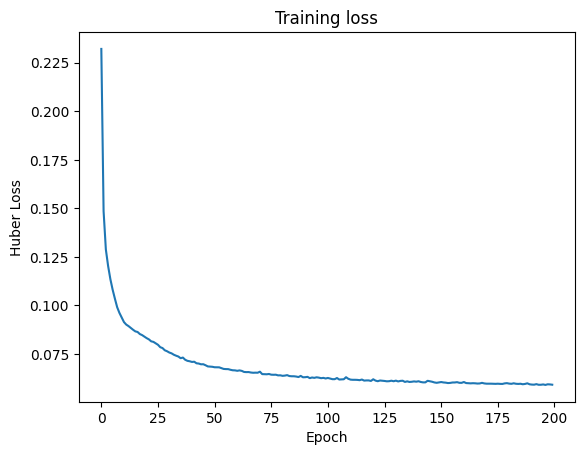


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [10]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(64, activation='tanh')(input_layer)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=200, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_tanh.keras")

colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_tanh = pd.concat([df_info_reset, df_ae_tanh], axis=1)

#### ReLU with dropout

In [11]:
'''print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(128, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='relu', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='relu')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=300, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_dropout = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_relu_dropout = pd.concat([df_info_reset, df_ae_relu_dropout], axis=1)'''

'print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")\n\ninput_dim = X_scaled.shape[1] \n\n# ==========================================\n# 1. MODEL ARCHITECTURE\n# ==========================================\n# Input\ninput_layer = layers.Input(shape=(input_dim,))\n\n# ENCODER (ReLU compression)\nencoded = layers.Dense(128, activation=\'relu\')(input_layer)\nencoded = layers.Dropout(0.2)(encoded)\nencoded = layers.Dense(64, activation=\'relu\')(encoded)\nencoded = layers.Dense(32, activation=\'relu\')(encoded)\n\n# BOTTLENECK (10-dimensional latent space)\nbottleneck_layer = layers.Dense(10, activation=\'relu\', name=\'dna_bottleneck\')(encoded)\n\n# DECODER (Reconstruction)\ndecoded = layers.Dense(32, activation=\'relu\')(bottleneck_layer)\ndecoded = layers.Dense(64, activation=\'relu\')(decoded)\ndecoded = layers.Dropout(0.2)(decoded)\ndecoded = layers.Dense(128, activation=\'relu\')(decoded)\n\n# Final output (returns to original number of columns, linear)\noutput_layer = la

#### Tanh with dropout

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.2137
Epoch 2/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1564
Epoch 3/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1426
Epoch 4/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1349
Epoch 5/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1304
Epoch 6/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1249
Epoch 7/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1214
Epoch 8/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1184
Epoch 9/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1162
Epoch 10/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1141
Epoch 11/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1126
Epoch 12/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1109
Epoch 13/300
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1099
Epoch 14/300
107/107 ━━━━━━━━━━━━━

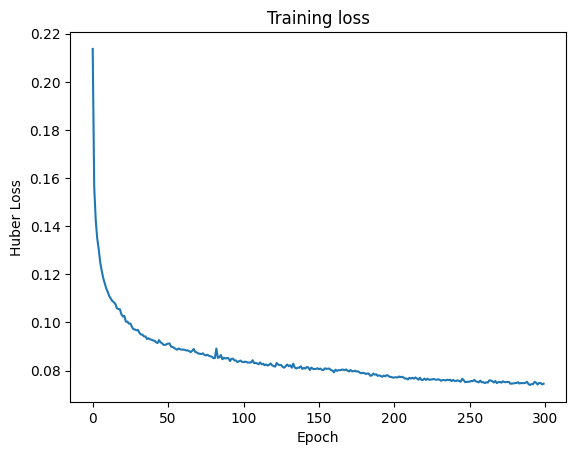


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [12]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (tanh compression)
encoded = layers.Dense(128, activation='tanh')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(64, activation='tanh')(encoded)
encoded = layers.Dense(32, activation='tanh')(encoded)

# BOTTLENECK (10-dimensional latent space)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='tanh')(bottleneck_layer)
decoded = layers.Dense(64, activation='tanh')(decoded)
decoded = layers.Dropout(0.2)(decoded)
decoded = layers.Dense(128, activation='tanh')(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=300, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_tanh_dropout.keras")

colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_tanh_dropout = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_tanh_dropout = pd.concat([df_info_reset, df_ae_tanh_dropout], axis=1)

#### ReLU + Tanh bottleneck with dropout

--- Building Deep Autoencoder (TensorFlow/Keras) ---

Training in progress...
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2850
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1972
Epoch 3/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1773
Epoch 4/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1652
Epoch 5/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1590
Epoch 6/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1542
Epoch 7/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1504
Epoch 8/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1468
Epoch 9/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1457
Epoch 10/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1433
Epoch 11/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1420
Epoch 12/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1402
Epoch 13/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1380
Epoch 14/100
107/107 ━━━━━━━━━━━━━

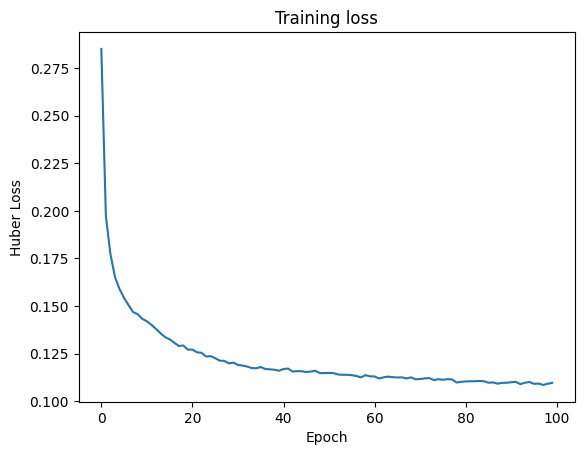


Extracting 10D DNA representation...
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [13]:
print("--- Building Deep Autoencoder (TensorFlow/Keras) ---")

input_dim = X_scaled.shape[1] 

# ==========================================
# 1. MODEL ARCHITECTURE
# ==========================================
# Input
input_layer = layers.Input(shape=(input_dim,))

# ENCODER (ReLU compression)
encoded = layers.Dense(64, activation='relu')(input_layer)
encoded = layers.Dropout(0.2)(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)

# BOTTLENECK (10-dimensional latent space, bounded by tanh)
bottleneck_layer = layers.Dense(10, activation='tanh', name='dna_bottleneck')(encoded)

# DECODER (Reconstruction)
decoded = layers.Dense(32, activation='relu')(bottleneck_layer)
decoded = layers.Dense(64, activation='relu')(decoded)
decoded = layers.Dropout(0.2)(decoded)

# Final output (returns to original number of columns, linear)
output_layer = layers.Dense(input_dim, activation='linear')(decoded)

# ==========================================
# 2. COMPILE AND TRAIN
# ==========================================
autoencoder = models.Model(inputs=input_layer, outputs=output_layer)
autoencoder.compile(optimizer='adam', loss='huber')

print("\nTraining in progress...")
autoencoder.fit(X_scaled, X_scaled, epochs=100, batch_size=32, verbose=1)
print("Training completed!")

plot_loss = autoencoder.history.history['loss']
plt.plot(plot_loss)
plt.title('Training loss')
plt.xlabel('Epoch')
plt.ylabel('Huber Loss')
plt.show()

# ==========================================
# 3. LATENT SPACE EXTRACTION
# ==========================================
print("\nExtracting 10D DNA representation...")

encoder = models.Model(inputs=input_layer, outputs=bottleneck_layer)
bottleneck = encoder.predict(X_scaled)

# Save reusable encoder for web app inference
#encoder.save("saved_models/encoder_relu_tanh_btn.keras")

colonne_ae = [f'AE_{i+1}' for i in range(10)]
df_ae_relu_tanh_btn = pd.DataFrame(bottleneck, columns=colonne_ae)
df_latent_ae_relu_tanh_btn = pd.concat([df_info_reset, df_ae_relu_tanh_btn], axis=1)

#### Testing Autoencoder

##### Similarity Functions

In [14]:
def trova_simili_ae(nome_giocatore, stagione_giocatore, df_latente, top_n=5, max_age=None, season_filter=None, same_position=False, same_league=False, same_preferred_foot=False):
    # Find player index by name and season
    mask_target = (
        (df_latente['player'].str.lower() == nome_giocatore.lower())
        & (df_latente['season'] == stagione_giocatore)
    )
    giocatore_idx = df_latente[mask_target].index

    if len(giocatore_idx) == 0:
        return "Player not found in the database."

    idx = giocatore_idx[0]
    giocatore_reale = df_latente.loc[idx, 'player']
    squadra_reale = df_latente.loc[idx, 'team']
    stagione = df_latente.loc[idx, 'season']
    ruolo = df_latente.loc[idx, 'pos']

    print(f"\n[AUTOENCODER] Searching similar players for: {giocatore_reale} ({squadra_reale} - {stagione})")

    # Extract target player's 10 latent values
    giocatore_vettore = df_latente.loc[idx, colonne_ae].values.reshape(1, -1)
    # Extract all players' latent values
    tutti_i_vettori = df_latente[colonne_ae].values

    # Compute cosine similarity
    similarita = cosine_similarity(giocatore_vettore, tutti_i_vettori)[0]

    # Assign scores
    df_latente_temp = df_latente.copy()
    df_latente_temp['Similarity_Score'] = similarita

    # Exclude target player from results
    df_latente_temp = df_latente_temp.drop(index=idx)

    # Optional age filter
    if max_age is not None:
        df_latente_temp = df_latente_temp[df_latente_temp['age'] <= max_age]

    # Optional season filter
    if season_filter is not None:
        df_latente_temp = df_latente_temp[df_latente_temp['season'] == season_filter]

    # Optional position filter
    if same_position:
        df_latente_temp = df_latente_temp[df_latente_temp['pos'] == ruolo]

    # Optional league filter
    if same_league:
        df_latente_temp = df_latente_temp[df_latente_temp['league'] == df_latente.loc[idx, 'league']]

    # Optional preferred-foot filter
    if same_preferred_foot:
        df_latente_temp = df_latente_temp[df_latente_temp['preferred_foot'] == df_latente.loc[idx, 'preferred_foot']]

    df_latente_temp = df_latente_temp[df_latente_temp['player'] != nome_giocatore]

    # Sort from most similar to least similar
    simili = df_latente_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()

    # Format score as a readable percentage
    simili['Match %'] = (simili['Similarity_Score'] * 100).round(1).astype(str) + '%'

    colonne_output = ['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']
    return simili[colonne_output]

In [15]:
def trova_simili_ensemble(
    nome_giocatore,
    stagione_giocatore,
    df_latente_a=df_latent_ae_relu_tanh_btn,
    df_latente_b=df_latent_ae_tanh_dropout,
    df_latente_c=df_latent_ae_tanh,
    top_n=5,
    max_age=None,
    season_filter=None,
    same_position=False,
    same_league=False
):
    # Target player
    mask_target = (
        (df_latente_a['player'].str.lower() == nome_giocatore.lower())
        & (df_latente_a['season'] == stagione_giocatore)
    )
    giocatore_idx = df_latente_a[mask_target].index

    if len(giocatore_idx) == 0:
        return "Player not found in the database."

    idx = giocatore_idx[0]
    giocatore_reale = df_latente_a.loc[idx, 'player']
    squadra_reale = df_latente_a.loc[idx, 'team']
    stagione = df_latente_a.loc[idx, 'season']
    ruolo = df_latente_a.loc[idx, 'pos']
    league = df_latente_a.loc[idx, 'league']

    print(f"\n[ENSEMBLE] Searching similar players for: {giocatore_reale} ({squadra_reale} - {stagione})")

    # Average cosine similarity from the three latent spaces
    vettore_a = df_latente_a.loc[idx, colonne_ae].values.reshape(1, -1)
    vettore_b = df_latente_b.loc[idx, colonne_ae].values.reshape(1, -1)
    vettore_c = df_latente_c.loc[idx, colonne_ae].values.reshape(1, -1)
    sim_a = cosine_similarity(vettore_a, df_latente_a[colonne_ae].values)[0]
    sim_b = cosine_similarity(vettore_b, df_latente_b[colonne_ae].values)[0]
    sim_c = cosine_similarity(vettore_c, df_latente_c[colonne_ae].values)[0]
    sim_ensemble = (sim_a + sim_b + sim_c) / 3

    df_temp = df_latente_a.copy()
    df_temp['Similarity_Score'] = sim_ensemble
    df_temp = df_temp.drop(index=idx)

    if max_age is not None:
        df_temp = df_temp[df_temp['age'] <= max_age]

    if season_filter is not None:
        df_temp = df_temp[df_temp['season'] == season_filter]

    if same_position:
        df_temp = df_temp[df_temp['pos'] == ruolo]

    if same_league:
        df_temp = df_temp[df_temp['league'] == league]

    df_temp = df_temp[df_temp['player'] != nome_giocatore]

    simili = df_temp.sort_values(by='Similarity_Score', ascending=False).head(top_n).copy()
    simili['Match %'] = (simili['Similarity_Score'] * 100).round(1).astype(str) + '%'

    return simili[['player', 'age', 'team', 'pos', 'league', 'season', 'Match %']]

##### Testing

###### Single Testing

In [16]:
# ==========================================
# 5. TEST THE MODEL
# ==========================================
target_player = "Riccardo Orsolini"
target_season = "2024 - 2025"
max_age = None

models_to_test = {
    #'Relu': df_latent_ae_relu,
    'Tanh': df_latent_ae_tanh,
    #'Mix ReLU': df_latent_ae_mix_relu,
    #'Mix Tanh': df_latent_ae_mix_tanh,
    #'ReLU + Dropout': df_latent_ae_relu_dropout,
    'Tanh + Dropout': df_latent_ae_tanh_dropout,
    'ReLU + Tanh bottleneck': df_latent_ae_relu_tanh_btn,
}

for model_name, model_df in models_to_test.items():
    print(f"\n===== Model: {model_name} =====")
    risultati_ae = trova_simili_ae(
        nome_giocatore=target_player,
        stagione_giocatore=target_season,
        df_latente=model_df,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=True
    )
    display(risultati_ae)

print("\n===== Model: Ensemble =====")
risultati_ensemble = trova_simili_ensemble(
    nome_giocatore=target_player,
    stagione_giocatore=target_season,
    top_n=5,
    max_age=max_age,
    season_filter=None,
    same_position=True,
    same_league=False
)
display(risultati_ensemble)


===== Model: Tanh =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,94.7%
1479,Álex Berenguer,28,Athletic Club,FW,ESP-La Liga,2023 - 2024,89.7%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,88.8%
1063,Randal Kolo Muani,25,Juventus,FW,ITA-Serie A,2024 - 2025,88.5%
1572,Ante Budimir,32,Osasuna,FW,ESP-La Liga,2023 - 2024,86.7%



===== Model: Tanh + Dropout =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,92.0%
1063,Randal Kolo Muani,25,Juventus,FW,ITA-Serie A,2024 - 2025,87.9%
2059,Justin Njinmah,22,Werder Bremen,FW,GER-Bundesliga,2023 - 2024,86.9%
905,Oliver Burke,27,Werder Bremen,FW,GER-Bundesliga,2024 - 2025,86.5%
470,Esteban Lepaul,24,Angers,FW,FRA-Ligue 1,2024 - 2025,85.8%



===== Model: ReLU + Tanh bottleneck =====

[AUTOENCODER] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,88.4%
3153,Niclas Füllkrug,29,Werder Bremen,FW,GER-Bundesliga,2022 - 2023,86.6%
752,Omar Marmoush,25,Eint Frankfurt,FW,GER-Bundesliga,2024 - 2025,85.7%
1479,Álex Berenguer,28,Athletic Club,FW,ESP-La Liga,2023 - 2024,82.3%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,82.2%



===== Model: Ensemble =====

[ENSEMBLE] Searching similar players for: Riccardo Orsolini (Bologna - 2024 - 2025)


,player,age,team,pos,league,season,Match %
1736,Georges Mikautadze,22,Metz,FW,FRA-Ligue 1,2023 - 2024,91.7%
1479,Álex Berenguer,28,Athletic Club,FW,ESP-La Liga,2023 - 2024,85.6%
1063,Randal Kolo Muani,25,Juventus,FW,ITA-Serie A,2024 - 2025,84.8%
365,Fábio Silva,22,Las Palmas,FW,ESP-La Liga,2024 - 2025,84.8%
1711,Alexandre Lacazette,32,Lyon,FW,FRA-Ligue 1,2023 - 2024,81.1%


###### Bulk Testing

In [17]:
# Single table with all results (target player x model)
target = ["Kevin De Bruyne", "Alessandro Bastoni", "Manuel Locatelli", "Andrea Pinamonti", 'Erling Haaland', "Xavi Simons", "Riccardo Orsolini"]
same_position = [False, False, False, False, False, False, False]
max_age = 23

target_same_position = dict(zip(target, same_position))
all_results = []

for giocatore in target:
    for model_name, model_df in models_to_test.items():
        res = trova_simili_ae(
            nome_giocatore=giocatore,
            stagione_giocatore=target_season,
            df_latente=model_df,
            top_n=5,
            max_age=max_age,
            season_filter=None,
            same_position=target_same_position[giocatore],
            same_league=False,
            same_preferred_foot=False
        )

        if isinstance(res, pd.DataFrame):
            res = res.copy()
            res["target_player"] = giocatore
            res["target_season"] = target_season
            res["model_used"] = model_name
            res["rank"] = range(1, len(res) + 1)
            all_results.append(res)

    # Add the ensemble result as well
    res_ensemble = trova_simili_ensemble(
        nome_giocatore=giocatore,
        stagione_giocatore=target_season,
        top_n=5,
        max_age=max_age,
        season_filter=None,
        same_position=target_same_position[giocatore],
        same_league=False
    )

    if isinstance(res_ensemble, pd.DataFrame):
        res_ensemble = res_ensemble.copy()
        res_ensemble["target_player"] = giocatore
        res_ensemble["target_season"] = target_season
        res_ensemble["model_used"] = "Ensemble"
        res_ensemble["rank"] = range(1, len(res_ensemble) + 1)
        all_results.append(res_ensemble)

# Final grouped DataFrame
grouped_results_table = pd.concat(all_results, ignore_index=True)

# Column order for readability
grouped_results_table = (
    grouped_results_table[
        ["target_player", "target_season", "model_used", "rank", "player", "age", "team", "pos", "league", "season", "Match %"]
    ]
    .sort_values(["target_player", "model_used", "rank"])
    .reset_index(drop=True)
)

display(grouped_results_table)


[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[ENSEMBLE] Searching similar players for: Kevin De Bruyne (Manchester City - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[ENSEMBLE] Searching similar players for: Alessandro Bastoni (Inter - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Manuel Locatelli (Juventus - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Manuel Locatelli (Juventus - 2024 - 2025)

[AUTOENCODER] Searching similar players for: Manuel Locatelli (Juventus - 2024 - 2025)

[ENSEMBLE] Search

,target_player,target_season,model_used,rank,player,age,team,pos,league,season,Match %
0,Alessandro Bastoni,2024 - 2025,Ensemble,1,Jules Koundé,23,Barcelona,DF,ESP-La Liga,2022 - 2023,88.7%
1,Alessandro Bastoni,2024 - 2025,Ensemble,2,Facundo Medina,23,Lens,DF,FRA-Ligue 1,2022 - 2023,84.4%
2,Alessandro Bastoni,2024 - 2025,Ensemble,3,Piero Hincapié,22,Leverkusen,DF,GER-Bundesliga,2024 - 2025,82.7%
3,Alessandro Bastoni,2024 - 2025,Ensemble,4,Miguel Gutiérrez,22,Girona,DF,ESP-La Liga,2023 - 2024,82.5%
4,Alessandro Bastoni,2024 - 2025,Ensemble,5,Matteo Ruggeri,21,Atalanta,DF,ITA-Serie A,2023 - 2024,82.4%
...,...,...,...,...,...,...,...,...,...,...,...
135,Xavi Simons,2024 - 2025,Tanh + Dropout,1,Matìas Soulé,21,Roma,"MF,DF",ITA-Serie A,2024 - 2025,94.8%
136,Xavi Simons,2024 - 2025,Tanh + Dropout,2,Niels Nkounkou,22,Eint Frankfurt,"DF,MF",GER-Bundesliga,2023 - 2024,94.6%
137,Xavi Simons,2024 - 2025,Tanh + Dropout,3,Kenan Yıldız,19,Juventus,"FW,MF",ITA-Serie A,2024 - 2025,94.5%
138,Xavi Simons,2024 - 2025,Tanh + Dropout,4,Dwight McNeil,22,Everton,"FW,MF",ENG-Premier League,2022 - 2023,94.3%


In [18]:
#grouped_results_table.to_csv("grouped_results_table.csv", index=False)

#### Choice explanation

To maximize accuracy and handle tactical nuances such as hybrid roles and statistical outliers, the final pipeline uses an ensemble of two autoencoders and averages their cosine similarity scores.

* Model A: the specialist (ReLU encoder with tanh bottleneck)
    * Architecture: Standard

            Input -> 64 -> Dropout -> 32 -> 10 -> 32 -> 64 -> Dropout -> Output.

    * Encoder activation: ReLU. This can create sparse intermediate representations and keep the model focused on the strongest signals.
    * Bottleneck activation: tanh. This constrains the 10D latent space to [-1, 1], which is compatible with cosine similarity.
    * Epochs & batch size: 100 epochs, batch size 32.

* Model B: the holistic model (tanh network with dropout)
    * Architecture: Deeper layers to capture highly non-linear and complex tactical relationships.

            Input -> 128 -> Dropout -> 64 -> 32 -> 10 -> 32 -> 64 -> Dropout -> 128 -> Output

    * Activation: tanh throughout. This keeps the latent space bounded and preserves sign information in the compressed representation.
    * Epochs & batch size: 300 epochs, batch size 32.

* Training hyperparameters (both models)
    * Loss function: Huber. A robust regression loss that is less sensitive to outliers than plain MSE.
    * Optimizer: Adam.

* Ensemble strategy
    * Implementation: Ensemble_Score = (Score_Model_A + Score_Model_B + Score_Model_C) / 3

    * Rationale: 
        * Model A is highly precise but can be rigid; 
        * Model B is tactically creative but can occasionally drift; 
        * Model C provides a stable baseline. 
        
        Averaging their raw Cosine Similarity scores stabilizes the final output. It boosts players recognized by all three architectures while heavily penalizing "hallucinations" (e.g., when a single model confuses a high-scoring winger with a pure striker).

* **NEXT STEP:**
Add spatial/GPS tracking data (e.g., heatmaps, average pitch positions, distance covered) to better contextualize on-ball events and definitively separate players with similar stats but different positional roles on the pitch.

#### Save csv models

In [ ]:
'''print("--- Estrazione finale e salvataggio dei database vettoriali ---")

# Nomi delle colonne latenti (le 10 dimensioni)
colonne_ae = [f'AE_{i+1}' for i in range(10)]

# 1. Modello A (Specialist: ReLU + Tanh Bottleneck)
# Usiamo i dataframe latenti che hai GIA' IN MEMORIA dopo l'addestramento
# Assumiamo che tu abbia creato df_latent_ae_relu_tanh_btn nel notebook
print("Salvataggio Modello A...")
df_latent_ae_relu_tanh_btn.to_csv('saved_models\database_dna_a.csv', index=False)

# 2. Modello B (Explorer: Tanh + Dropout)
print("Salvataggio Modello B...")
df_latent_ae_tanh_dropout.to_csv('saved_models\database_dna_b.csv', index=False)

# 3. Modello C (Balancer: Pure Tanh)
print("Salvataggio Modello C...")
df_latent_ae_tanh.to_csv('saved_models\database_dna_c.csv', index=False)

print("✅ File CSV generati con successo! Pronti per essere caricati nell'app web o usati per il clustering.")'''

'print("--- Estrazione finale e salvataggio dei database vettoriali ---")\n\n# Nomi delle colonne latenti (le 10 dimensioni)\ncolonne_ae = [f\'AE_{i+1}\' for i in range(10)]\n\n# 1. Modello A (Specialist: ReLU + Tanh Bottleneck)\n# Usiamo i dataframe latenti che hai GIA\' IN MEMORIA dopo l\'addestramento\n# Assumiamo che tu abbia creato df_latent_ae_relu_tanh_btn nel notebook\nprint("Salvataggio Modello A...")\ndf_latent_ae_relu_tanh_btn.to_csv(\'database_dna_a.csv\', index=False)\n\n# 2. Modello B (Explorer: Tanh + Dropout)\nprint("Salvataggio Modello B...")\ndf_latent_ae_tanh_dropout.to_csv(\'database_dna_b.csv\', index=False)\n\n# 3. Modello C (Balancer: Pure Tanh)\nprint("Salvataggio Modello C...")\ndf_latent_ae_tanh.to_csv(\'database_dna_c.csv\', index=False)\n\nprint("✅ File CSV generati con successo! Pronti per essere caricati nell\'app web o usati per il clustering.")'

## Anomaly Detection

### Remap of Roles

In [20]:
pos_mapping = {
    "MF,FW": "OM",
    "MF,DF": "MF",
    "FW,MF": "OW",
    "FW,DF": "OW",
    "DF,MF": "FB",
    "DF,FW": "FB",
}

df["pos"] = df["pos"].replace(pos_mapping)

if "df_info" in globals():
    df_info["pos"] = df_info["pos"].replace(pos_mapping)

if "df_info_reset" in globals():
    df_info_reset["pos"] = df_info_reset["pos"].replace(pos_mapping)

### SVM

In [21]:
role_target = "OM"
df_info_base = df_info_reset.copy() if "df_info_reset" in globals() else df_info.copy()

if "pos" not in df_info_base.columns:
    raise KeyError("Column 'pos' not found in the info dataframe.")

mask_role_svm = df_info_base["pos"].fillna("").str.contains(role_target, regex=False)
df_role_svm = df_info_base.loc[mask_role_svm].copy()
X_role_svm_scaled = X_scaled[mask_role_svm.values]

if len(df_role_svm) < 10:
    raise ValueError(f"Too few players for role {role_target}: {len(df_role_svm)}")

# 2) Anomaly Detection (One-Class SVM)
from sklearn.svm import OneClassSVM
svm_one_class = OneClassSVM(nu=0.05, kernel="rbf", gamma="scale")

# 3) Training and Assignment on ORIGINAL SCALED data (no PCA)
df_role_svm["Anomaly_SVM"] = svm_one_class.fit_predict(X_role_svm_scaled)

# 4) Output and Analysis
print("Count of normal players (1) and anomalies (-1):")
print(df_role_svm["Anomaly_SVM"].value_counts().sort_index())

required_cols = ["player", "team", "age", "pos", "Anomaly_SVM"]
missing_cols = [c for c in required_cols if c not in df_role_svm.columns]
if missing_cols:
    raise KeyError(f"Missing columns for anomaly output: {missing_cols}")

aliens_svm = df_role_svm[df_role_svm["Anomaly_SVM"] == -1].copy()
display(aliens_svm[["player", "team", "age", "pos", "Anomaly_SVM"]].head(10))

Count of normal players (1) and anomalies (-1):
Anomaly_SVM
-1     23
 1    261
Name: count, dtype: int64


,player,team,age,pos,Anomaly_SVM
46,Mikkel Damsgaard,Brentford,24,OM,-1
204,Nicolás Domínguez,Nott'ham Forest,26,OM,-1
248,Lucas Paquetá,West Ham,26,OM,-1
260,Matheus Cunha,Wolves,25,OM,-1
428,Takefusa Kubo,Real Sociedad,23,OM,-1
617,Sofiane Diop,Nice,24,OM,-1
749,Mario Götze,Eint Frankfurt,32,OM,-1
922,Ademola Lookman,Atalanta,26,OM,-1
960,Mattia Felici,Cagliari,23,OM,-1
1071,Fisayo Dele-Bashiru,Lazio,23,OM,-1


### Tactical Profiling: Finding Hybrid and Mislabelled Roles with the KNN Classifier

Instead of using KNN to classify new data, we use its *classification errors* on the training set (through cross-validation) as a scouting tool.
If KNN looks at a defender's data and says "For me this is a midfielder", we have just found a player who breaks the patterns of the official role and behaves like a playmaker or ball-progressor.

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict

def tactical_profiling_knn(df_info_input, X_scaled_input, macro_role="DF", n_neighbors=5, weights="distance", cv=5, top_n=15):
    """
    Learn role patterns with KNN and print the players whose predicted role differs
    from the selected macro role.
    """
    df_knn = df_info_input.copy()

    if "pos" not in df_knn.columns:
        raise KeyError("Column 'pos' not found in the info dataframe.")

    # Keep the current Macro_Role computation unchanged
    df_knn["Macro_Role"] = df_knn["pos"]

    valid_mask = df_knn["Macro_Role"].notna() & (df_knn["Macro_Role"] != "")
    df_knn = df_knn.loc[valid_mask].copy()
    X_knn = X_scaled_input[valid_mask.values]

    knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights=weights)
    df_knn["Predicted_Role"] = cross_val_predict(
        knn,
        X_knn,
        df_knn["Macro_Role"],
        cv=cv
    )

    hybrid_profiles = df_knn[df_knn["Macro_Role"] != df_knn["Predicted_Role"]].copy()

    print("Confusion table (true role vs predicted role):")
    role_confusion = pd.crosstab(
        df_knn["Macro_Role"],
        df_knn["Predicted_Role"],
        rownames=["Macro_Role"],
        colnames=["Predicted_Role"]
    )
    display(role_confusion)

    mismatched_role = hybrid_profiles[hybrid_profiles["Macro_Role"] == macro_role].copy()

    print(f"\nPlayers with Macro_Role = {macro_role} and a different predicted role:")
    if mismatched_role.empty:
        print(f"No mismatched players found for role {macro_role}.")
    else:
        display(mismatched_role[["player", "team", "age", "Macro_Role", "Predicted_Role"]].head(top_n))

    return {
        "df_knn": df_knn,
        "hybrid_profiles": hybrid_profiles,
        "role_confusion": role_confusion,
        "mismatched_role": mismatched_role
    }


# Example usage
knn_results = tactical_profiling_knn(
    df_info_input=df_info_reset if "df_info_reset" in globals() else df_info,
    X_scaled_input=X_scaled,
    macro_role="FB",
    top_n=100
 )

Confusion table (true role vs predicted role):


Predicted_Role,DF,FB,FW,MF,OM,OW
Macro_Role,,,,,,
DF,1062,37,1,65,4,5
FB,119,18,1,36,9,7
FW,0,0,345,6,26,86
MF,53,12,5,731,51,23
OM,3,3,31,89,79,79
OW,4,3,114,29,81,179



Players with Macro_Role = FB and a different predicted role:


,player,team,age,Macro_Role,Predicted_Role
42,Keane Lewis-Potter,Brentford,23,FB,DF
61,Mats Wieffer,Brighton,24,FB,MF
78,Reece James,Chelsea,24,FB,DF
124,Ben Johnson,Ipswich Town,24,FB,DF
165,Matheus Nunes,Manchester City,25,FB,DF
...,...,...,...,...,...
1879,Maximilian Wittek,Bochum,27,FB,MF
1887,Fabian Nürnberger,Darmstadt 98,24,FB,DF
1889,Klaus Gjasula,Darmstadt 98,33,FB,DF
1894,Matthias Bader,Darmstadt 98,26,FB,MF


### Autoencoder Reconstruction Error

## End

In [23]:
end_time = time.time()

In [24]:

elapsed_time = end_time - start_time
elapsed_minutes = round(elapsed_time / 60)
remaining_seconds = round(elapsed_time % 60)
print(f"\nTotal execution time: {elapsed_minutes:.0f}.{remaining_seconds:.0f} min")


Total execution time: 4.23 min
